In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Install libraries

In [79]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-x635o_mu
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-x635o_mu
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.1 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=53ff3cffcb12279175cbd14297d922e51179b8631db2e45b781e75ac3c311010
  Stored in directory: /tmp/pip-ephem-wheel-cache-_liqb3q3/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


# Import Libraries

In [2]:
import json
import pandas as pd
import torch
import transformers
import tensorflow as tf
from transformers import CLIPProcessor, CLIPModel, CLIPTokenizer
from typing import ForwardRef
from PIL import Image
# import clip
import os
import sys
import numpy as np
sys.path.append('/content/drive/MyDrive/Thesis/code/')
from Ensemble import Ensemble

In [3]:
Ensemble

Ensemble.Ensemble

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Best Params from (Text checkworthy )

-- https://colab.research.google.com/drive/1XrAT6BT24j6q8_FCl_gawN6fHQ7Y4OrH?authuser=2#scrollTo=zFxAC3NGvIdG

In [6]:
best_param_rfc = {
 'bootstrap': False,
 'ccp_alpha': 0.01,
 'class_weight': 'balanced',
 'criterion': 'entropy',
 'max_depth': 30,
 'max_features': 'sqrt',
 'min_impurity_decrease': 0.01,
 'min_samples_leaf': 4,
 'min_samples_split': 2,
 'n_estimators': 1788
}

new_best_param_rfc = {
 'n_estimators': 733,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'min_impurity_decrease': 0.0,
 'max_features': 'sqrt',
 'max_depth': 30,
 'criterion': 'entropy',
 'class_weight': 'balanced',
 'ccp_alpha': 0.01,
 'bootstrap': False
 }
best_rfc = {
  'bootstrap': False,
 'ccp_alpha': 0.01,
 'class_weight': 'balanced', #
 'criterion': 'entropy',
 'max_depth': 60,
 'max_features': 'log2', #
 'min_impurity_decrease': 0.1, #
 'min_samples_leaf': 2,
 'min_samples_split': 10,
 'n_estimators': 944
  }


best_param_xgb = {
 'colsample_bytree': 1.0,
 'eval_metric': 'logloss',
 'gamma': 0,
 'learning_rate': 0.05,
 'max_depth': 30,
 'min_child_weight': 5,
 'n_estimators': 1742,
 'objective': 'binary:logistic',
 'reg_alpha': 0,
 'reg_lambda': 0.01,
 'scale_pos_weight': 5,
 'subsample': 0.6
}

new_best_param_xgb ={'colsample_bytree': 0.6,
 'eval_metric': 'logloss',
 'gamma': 0.1,
 'learning_rate': 0.05,
 'max_depth': 110,
 'min_child_weight': 1,
 'n_estimators': 1228,
 'objective': 'binary:logistic',
 'reg_alpha': 0.1,
 'reg_lambda': 0.1,
 'scale_pos_weight': 10,
 'subsample': 0.6
 }

best_xgb = {
'colsample_bytree': 0.8, #
 'eval_metric': 'auc',
 'gamma': 0.1,
 'learning_rate': 0.05,
 'max_depth': 100, #
 'min_child_weight': 3,
 'n_estimators': 1485,
 'objective': 'binary:logistic',
 'reg_alpha': 10, #
 'reg_lambda': 0, #
 'scale_pos_weight': 20, #
 'subsample': 0.6 #
              }

best_param_dt = {
 'ccp_alpha': 0.01, #
 'class_weight': 'balanced',
 'criterion': 'log_loss', #
 'max_depth': 10,
 'max_features': None,
 'max_leaf_nodes': 10,
 'min_samples_leaf': 1, #
 'min_samples_split': 2,
 'splitter': 'best' #
}

new_best_param_dt = {
 'ccp_alpha': 0.0,
 'class_weight': 'balanced',
 'criterion': 'gini',
 'max_depth': 10,
 'max_features': None,
 'max_leaf_nodes': 10,
 'min_samples_leaf': 10,
 'min_samples_split': 20,
 'splitter': 'random'
 }

best_dt = {
 'ccp_alpha': 0.0,
 'class_weight': 'balanced',
 'criterion': 'gini',
 'max_depth': 10,
 'max_features': 'sqrt',
 'max_leaf_nodes': 10,
 'min_samples_leaf': 10,
 'min_samples_split': 5,
 'splitter': 'random'
 }


best_param_knn = {
   'metric': 'minkowski',
   'n_neighbors': 3,#
   'p': 2,
   'weights': 'distance'
}
new_best_param_knn = {
  'metric': 'minkowski',
  'n_neighbors': 3,#
  'p': 2,
  'weights': 'distance'
  }
best_knn = {'metric': 'euclidean', 'n_neighbors': 15, 'p': 1, 'weights': 'uniform'}

best_param_gdb = {
 'learning_rate': 0.27616382277289797,#
 'max_depth': 3,#
 'max_features': None,
 'min_samples_leaf': 5,
 'min_samples_split': 16,
 'n_estimators': 255,
 'subsample': 0.9244569121330419#
}
new_best_param_gdb = {
 'learning_rate': np.float64(0.14374982585607735),#
 'max_depth': 9,#
 'max_features': None,
 'min_samples_leaf': 11,
 'min_samples_split': 5,
 'n_estimators': 153,
 'subsample': np.float64(0.8540362888980227)#
 }
best_gdb = {'learning_rate': np.float64(0.25463842853645025),#
 'max_depth': 3,#
 'max_features': None,
 'min_samples_leaf': 3,
 'min_samples_split': 2,
 'n_estimators': 172,
 'subsample': np.float64(0.5370223258670452)#
 }
best_param_lgbm = {
 'bagging_fraction': 0.856135294962221,
 'bagging_freq': 4,
 'feature_fraction': 0.6424202471887338,
 'lambda_l1': 0.036886947354532795,
 'lambda_l2': 0.6095643339798968,
 'learning_rate': 0.16080370696865845,#
 'max_depth': 8, #
 'min_child_samples': 32,
 'n_estimators': 278,
 'num_leaves': 20 #
}
new_best_param_lgbm = {
 'bagging_fraction': np.float64(0.8641081743059298),
 'bagging_freq': 7, #
 'feature_fraction': np.float64(0.7351503172230192),
 'lambda_l1': np.float64(0.983423140894843),#
 'lambda_l2': np.float64(0.39882444244455306), #
 'learning_rate': np.float64(0.2549295619658152),#
 'max_depth': 3, #
 'min_child_samples': 18,
 'n_estimators': 173,
 'num_leaves': 78 #
 }
best_lgbm = {'bagging_fraction': np.float64(0.8636359979282104),
 'bagging_freq': 7, #
 'feature_fraction': np.float64(0.7852219872026998), #
 'lambda_l1': np.float64(0.5208342600258237), #
 'lambda_l2': np.float64(0.9611720243493491), #
 'learning_rate': np.float64(0.2633601546034454),#
 'max_depth': 4, #
 'min_child_samples': 33,
 'n_estimators': 203,
 'num_leaves': 79 #
               }
best_param_adb = {
  'learning_rate': 0.34370861113902185,#
  'n_estimators': 153
}
new_best_param_adb = {
    'learning_rate': np.float64(0.7168573438476171),#
    'n_estimators': 212
 }
best_adb = {'learning_rate': np.float64(0.010778765841014329)#
, 'n_estimators': 237}
best_param_lr = {
  'solver': 'liblinear',
 'penalty': 'l2',
 'l1_ratio': 0.5,
 'class_weight': None,
 'C': 206.913808111479
  }

new_best_param_lr = {

 'C': 1,
 'class_weight': None,
 'fit_intercept': False,
 'intercept_scaling': 1,
 'penalty': 'l2',
 'solver': 'lbfgs',
 'tol': 0.0001
}
best_lr = {
  'C': 1, #
 'class_weight': 'balanced', #
 'fit_intercept': False,
 'intercept_scaling': 1,
 'penalty': None,
 'solver': 'sag', #
 'tol': 0.0001}

# Mdels

In [81]:
# clip.available_models()
# device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

100%|███████████████████████████████████████| 338M/338M [00:08<00:00, 44.1MiB/s]


In [7]:
checkpoint = "openai/clip-vit-base-patch32"
clipmodel = CLIPModel.from_pretrained(checkpoint).to(device)
processor = CLIPProcessor.from_pretrained(checkpoint)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

# Load Data

## file paths (json, image folder)

In [9]:
## json file paths - dev, dev_test, train
c_m_e_dev = "/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/checkthat_labeled/CT23_1A_checkworthy_multimodal_english_v2/CT23_1A_checkworthy_multimodal_english_dev.jsonl"

c_m_e_dev_test = "/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/checkthat_labeled/CT23_1A_checkworthy_multimodal_english_v2/CT23_1A_checkworthy_multimodal_english_dev_test.jsonl"

c_m_e_train = "/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/checkthat_labeled/CT23_1A_checkworthy_multimodal_english_v2/CT23_1A_checkworthy_multimodal_english_train.jsonl"

## json file paths test_gold (with label), test (without label)
c_m_e_test_gold = "/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/checkthat_labeled/CT23_1A_checkworthy_multimodal_english_test_gold/CT23_1A_checkworthy_multimodal_english_test_gold.jsonl"

c_m_e_test = "/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/checkthat_labeled/CT23_1A_checkworthy_multimodal_english_test/CT23_1A_checkworthy_multimodal_english_test.jsonl"


## image folder (dev, dev_test, train)
c_m_e_dev_image = "/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/checkthat_labeled/CT23_1A_checkworthy_multimodal_english_v2" #/images_labeled/dev"

c_m_e_dev_test_image = "/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/checkthat_labeled/CT23_1A_checkworthy_multimodal_english_v2" #/images_labeled/dev_test"

c_m_e_train_image = "/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/checkthat_labeled/CT23_1A_checkworthy_multimodal_english_v2" #/images_labeled/train"

## image folder (test)
c_m_e_test_image = "/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/checkthat_labeled/CT23_1A_checkworthy_multimodal_english_test" #/images_labeled/test"

## check the data

In [ ]:
# with open(c_m_e_dev, 'r', encoding="utf-8") as file:
#   for line in file:
#     print(line)
# images_labeled/dev/1158363945645723648.jpg

In [ ]:
{"tweet_id": "1157009286142332928", "tweet_url": "https://twitter.com/user/status/1157009286142332928", "tweet_text": "Getting ready for lommel 254 photo's where taken between 13:04 en 15:49. See them al on https://t.co/ytItFEGJLy Also digital downloads and prints https://t.co/mW8cAElvRt", "ocr_text": "", "class_label": "No", "image_path": "images_labeled/dev/1157009286142332928.jpg", "image_url": "http://pbs.twimg.com/media/EA6Fz3GWwAAM0rA.jpg"}

# Process the data

- images: typing.Union[ForwardRef('PIL.Image.Image'), numpy.ndarray, ForwardRef('torch.Tensor'), list['PIL.Image.Image'], list[numpy.ndarray], list['torch.Tensor'], NoneType] = None
- text: str | list[str] | list[list[str]] | None = None

## Image

### acces the image and normalize, rescale

In [92]:
file_path = os.path.join(c_m_e_dev_image, "images_labeled/dev/1158363945645723648.jpg")

text = "Getting ready for lommel 254 photo's where taken between 13:04 en 15:49. See them al on https://t.co/ytItFEGJLy Also digital downloads and prints https://t.co/mW8cAElvRt"

inputs = processor(Image.open(file_path), text, return_tensors = "pt", padding = True)

inputs

{'pixel_values': tensor([[[[-0.9893, -0.9893, -0.9893,  ..., -0.5806, -0.5660, -0.5660],
          [-0.9893, -0.9748, -0.9748,  ..., -0.5660, -0.5514, -0.5514],
          [-1.0039, -0.9893, -0.9893,  ..., -0.5368, -0.5368, -0.5222],
          ...,
          [-1.0915, -1.2667, -1.3543,  ..., -1.2375, -1.4857, -1.6901],
          [-1.1937, -1.2375, -0.9602,  ..., -1.0915, -0.8288, -0.7996],
          [-0.9456, -0.5660, -0.6536,  ..., -0.9893, -0.9310, -0.9748]],

         [[ 0.2289,  0.2289,  0.2289,  ...,  0.4841,  0.4991,  0.4991],
          [ 0.2289,  0.2439,  0.2439,  ...,  0.4991,  0.5141,  0.5141],
          [ 0.2139,  0.2289,  0.2289,  ...,  0.5141,  0.5291,  0.5291],
          ...,
          [-1.0767, -1.1068, -1.1968,  ..., -1.0317, -1.1368, -1.1968],
          [-1.1518, -1.0017, -0.5665,  ..., -0.9117, -0.5815, -0.6115],
          [-0.7616, -0.1163, -0.0712,  ..., -0.7316, -0.5815, -0.7016]],

         [[ 1.3638,  1.3638,  1.3638,  ...,  1.5060,  1.5202,  1.5202],
          [ 1

In [94]:
output = clipmodel(**inputs)
image_embedding = output.image_embeds
text_embedding = output.text_embeds

In [13]:
type(image_embedding)

torch.Tensor

In [23]:
image_embedding_np = image_embedding.detach().numpy()
text_embedding_np = text_embedding.detach().numpy()

In [17]:
# t1 = [[1, 2, 3],[4, 5, 6]]
# t2 = [[1, 2, 9],[14, 25, 36]]
# tf.concat([t1, t2], 1)

<tf.Tensor: shape=(2, 6), dtype=int32, numpy=
array([[ 1,  2,  3,  1,  2,  9],
       [ 4,  5,  6, 14, 25, 36]], dtype=int32)>

In [25]:
print(image_embedding_np.shape)
print(text_embedding_np.shape)

(1, 512)
(1, 512)


In [33]:
data = tf.concat([image_embedding_np, text_embedding_np], 1)
data.shape

TensorShape([1, 1024])

In [35]:
data

<tf.Tensor: shape=(1, 1024), dtype=float32, numpy=
array([[-0.01751088,  0.00273393,  0.004063  , ..., -0.16594906,
        -0.01946602, -0.02533397]], dtype=float32)>

In [34]:
data[:,-1]

<tf.Tensor: shape=(1,), dtype=float32, numpy=array([-0.02533397], dtype=float32)>

### text process

In [35]:
# text = "Getting ready for lommel 254 photo's where taken between 13:04 en 15:49. See them al on https://t.co/ytItFEGJLy Also digital downloads and prints https://t.co/mW8cAElvRt"



# Prepare the data

## method 1
  - train the classical model on the embeddings ( train dataset ).
  - test on the dev test.

In [52]:
# df = pd.DataFrame(columns=['id', 'text_embedding', 'image_embedding', 'label'])
# df

## {'tweet_id': '1222845188567003136', 'tweet_url': 'https://twitter.com/user/status/1222845188567003136', 'tweet_text': 'Coronavirus: DED warns pharmacies against hiking prices of face masks https://t.co/ZBvkOKiuex https://t.co/GOiAsDGP75', 'ocr_text': 'WARNING\nM 8210\ncertain particles\nreut in eickness\nFor proper use, see\nor or box or call 3M\n0-247-3941. NIOSH\nN95\nagainst certain particies.\nheips protect\nЗи 8270\nMisuse may result in sickness\nsupervisor or box or call 3M\nor death. For proper use, see\nThis respirator helps protect\n1-800-247-3941. NIOSH\nCM0007\nLOF R17271\nAWARNING\nARNING\n3M 8210\nIC-84A 0007\nT R17271\ntin particles\nsicieness\nFapoper use, see\nbox or cel 3M\nB3C-841 NIOSH\nN95\nTC-8AU\nLOTE R17271\nwING\nN95\nM 8210\n', 'class_label': 'Yes', 'image_path': 'images_labeled/train/1222845188567003136.jpg', 'image_url': 'http://pbs.twimg.com/media/EPhrN-SU4AAKvGf.jpg'}

In [72]:
with open(c_m_e_train, 'r', encoding="utf-8") as file:
  for line in file:
    data = json.loads(line)
    print(data)

    # tweet_text, ocr_text, class_label, image_path

{'tweet_id': '1222845188567003136', 'tweet_url': 'https://twitter.com/user/status/1222845188567003136', 'tweet_text': 'Coronavirus: DED warns pharmacies against hiking prices of face masks https://t.co/ZBvkOKiuex https://t.co/GOiAsDGP75', 'ocr_text': 'WARNING\nM 8210\ncertain particles\nreut in eickness\nFor proper use, see\nor or box or call 3M\n0-247-3941. NIOSH\nN95\nagainst certain particies.\nheips protect\nЗи 8270\nMisuse may result in sickness\nsupervisor or box or call 3M\nor death. For proper use, see\nThis respirator helps protect\n1-800-247-3941. NIOSH\nCM0007\nLOF R17271\nAWARNING\nARNING\n3M 8210\nIC-84A 0007\nT R17271\ntin particles\nsicieness\nFapoper use, see\nbox or cel 3M\nB3C-841 NIOSH\nN95\nTC-8AU\nLOTE R17271\nwING\nN95\nM 8210\n', 'class_label': 'Yes', 'image_path': 'images_labeled/train/1222845188567003136.jpg', 'image_url': 'http://pbs.twimg.com/media/EPhrN-SU4AAKvGf.jpg'}
{'tweet_id': '1034562071453622272', 'tweet_url': 'https://twitter.com/user/status/10345620

In [97]:
caption = "Coronavirus: DED warns pharmacies against hiking prices of face masks https://t.co/ZBvkOKiuex https://t.co/GOiAsDGP75"
ocr_text = "WARNING\nM 8210\ncertain particles\nreut in eickness\nFor proper use, see\nor or box or call 3M\n0-247-3941. NIOSH\nN95\nagainst certain particies.\nheips protect\nЗи 8270\nMisuse may result in sickness\nsupervisor or box or call 3M\nor death. For proper use, see\nThis respirator helps protect\n1-800-247-3941. NIOSH\nCM0007\nLOF R17271\nAWARNING\nARNING\n3M 8210\nIC-84A 0007\nT R17271\ntin particles\nsicieness\nFapoper use, see\nbox or cel 3M\nB3C-841 NIOSH\nN95\nTC-8AU\nLOTE R17271\nwING\nN95\nM 8210\n"

text = caption + " " + ocr_text
# print(text)

image_file_path = os.path.join(c_m_e_train_image, "images_labeled/train/1222845188567003136.jpg")
# text = data["tweet_text"] + " " + data["ocr_text"]

inputs = processor(Image.open(image_file_path), text, return_tensors = "pt", padding = True, truncation = True) ## by default  for max_position_embedding = 77

# inputs

data = clipmodel(**inputs)
text_embedding = data.text_embeds
image_embedding = data.image_embeds
print(text_embedding.shape)

print(image_embedding.shape)

torch.Size([1, 512])
torch.Size([1, 512])


In [89]:
# image_pil = preprocess(Image.open(image_file_path))
# print(image_pil.shape)
# text_pil = clip.tokenize(text)
# print(text_pil.shape)

In [63]:
# text = "he llo world"
# text_2 = " "

# final_text = text.join(text_2) if len(text_2) != 0 or text_2 != " " else text
# print(final_text)

### function for convert the json data into pd dataframe (tweet_id, class_label, image_embeddings, text_embeddings)

In [26]:
# df_train_org['converted_embedding'].iloc[0]
def convert_to_numpy_array(embd_str):
    #print(f"string: {embd_str}")
    #print(type(embd_str))
    embd_str_clean = embd_str.replace("\n", " ").replace(" ", " ")
    #print(type(embd_str_clean))
    #print(f"string cleansing: {embd_str_clean}")
    embd_str_clean = embd_str_clean.strip('[]')
    #print(type(embd_str_clean))
    #print(f"removing the outer brackets {embd_str_clean}")
    embd_list = embd_str_clean.split()
    #print(f"Split the string into individual values {embd_list}")
    embed_array = np.array(embd_list, dtype = float)
    #print(f"list to array {embed_array}")
    return embed_array

In [10]:
# text =  image caption  + ocr text
# image
def process_data(json_file_path, image_folder_path, devide = device):
  list_of_data = []
  with open(json_file_path, 'r', encoding="utf-8") as file:
    for line in file:
      data = json.loads(line)
      # print(data["tweet_id"])
      # print("\n")
      image_file_path = os.path.join(image_folder_path, data["image_path"])
      text = data["tweet_text"] + " " + data["ocr_text"]

      inputs = processor(Image.open(image_file_path), text, return_tensors = "pt", padding = True, truncation=True).to(device) # ## by default  for max_position_embedding = 77, so set truncation = True to avoide error

      output = clipmodel(**inputs)
      image_embedding = output.image_embeds
      text_embedding = output.text_embeds
      # text embedding
      text_embedding_np = text_embedding.detach().cpu().numpy()
      # image embedding
      image_embedding_np = image_embedding.detach().cpu().numpy()


      list_of_data.append({
                            'tweet_id': data["tweet_id"],
                            'text_embedding': text_embedding_np,
                            'image_embeddings': image_embedding_np,
                            'class_label': data["class_label"]
                            })

  return list_of_data


In [100]:
training_data = process_data(c_m_e_train, c_m_e_train_image)
dev_test_data = process_data(c_m_e_dev_test, c_m_e_dev_test_image)

1222845188567003136


1034562071453622272


1034035319220391936


1222950237557288960


1034839004930289665


1033810845422247936


1222378720008208385


1128739362584375296


1035164871304855552


1035126808549576704


1222927469105352705


1222666002913206272


1237053111031812096


1145935295969468416


1242017129391517696


1034090899356217344


1033049048108822530


1222641503081766915


1239641033870319616


1034771621121286145


1222912089494294530


1144155077814284290


1176155944155340800


1125490654304460800


1222434982590849025


1035271957976162310


1189182602441183237


1222420121286668291


1238595573990576128


1168271562962886657


1222764644902662145


1033814491916578817


1222897266626719746


1034493871353409536


1216977680467402752


1035323378561765377


1222639846910582784


1222551285330825223


1034576785785016320


1032716377642033152


1034938848319610881


1246325000275210242


1222431716012326912


1222391241020588038


1175828753521532931


1168919121

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Streaming output truncated to the last 5000 lines.


1033353779108818946


1032981741592563712


1181058833881456640


1222803044795994114


1222568653356445703


1222965057308495872


1033923848595533824


1034861168857309186


1032968371137069056


1124367850943254529


1222626623779897345


1222567427847921669


1218569257891631104


1143325773249556480


1146101440991117312


1222406016886697984


1222650828705665024


1123679091146788864


1222506162475749376


1033230356500033536


1222596436652699651


1156855762003476482


1223119066904199168


1222467172829728768


1172074664543150080


1222814516997738496


1222837244026851329


1034362868819484672


1170669394118217728


1032682571505852417


1032620485811560454


1222903569319256065


1124043684071317504


1034086372766883841


1207674028116320259


1222411907337986049


1222420042165489665


1222915947008315392


1249894182459564032


1153191833016700929


1033881270051209216


1212238118675369985


1222458500804202497


1

In [130]:
test_data = process_data(c_m_e_test_gold, c_m_e_test_image)

1196687191747039232


981622723934859264


1473613189573058561


1222918922535604227


1164297159807852547


1221942799165247488


1386219570571194368


1222491887313018880


1222938447805079553


946308084368060416


1222483271679971330


1380548489046761473


1222394564725465088


1022193728247746561


1294608049899020293


1222672493292507140


1379012469075673089


1225418650569650177


974661838641270784


1474716201729277953


1432186935125159936


1247504779154243584


1047418463323545600


1215040506390073344


1222512061856567296


1128792024751255556


1039844252338073600


1340989825541935104


1379898742011260932


1381239983353311240


1245125842449154048


1034002753906003973


1249939118013874177


1299081314969231376


1039813881999372288


1120513082948837381


1070586006682906625


1203632113855221760


1383691965145878530


1335578344918667265


1296776489703153664


1245350467766562819


1034872995850997760


1134776281361371136


1250791104120795139


1247510825071

In [30]:
## save into a csv file for train and test and later uses
# multimodal_train = pd.DataFrame(training_data)
# multimodal_dev_test = pd.DataFrame(dev_test_data)

# multimodal_train.to_csv("/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/created_csv_files/multimodal_train_labeled_1.csv")
# multimodal_dev_test.to_csv("/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/created_csv_files/multimodal_dev_test_1.csv")

train_data = pd.read_csv("/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/created_csv_files/multimodal_train_labeled_1.csv")

dev_data = pd.read_csv("/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/created_csv_files/multimodal_dev_test_1.csv")


test_data = pd.read_csv("/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/created_csv_files/multimodal_test_gold_1.csv")

In [131]:
# multimodal_test_gold = pd.DataFrame(test_data)
# multimodal_test_gold.to_csv("/content/drive/MyDrive/MultiModal-Checkworthiness-Claim/created_csv_files/multimodal_test_gold_1.csv")

In [31]:
train_data["class_label"] = train_data["class_label"].apply(lambda x: 1 if x == "Yes" else 0)

test_data["class_label"] = test_data["class_label"].apply(lambda x: 1 if x == "Yes" else 0)

dev_data["class_label"] = dev_data["class_label"].apply(lambda x: 1 if x == "Yes" else 0)

In [32]:
dev_data["text_embedding"] = dev_data["text_embedding"].apply(convert_to_numpy_array)
dev_data["image_embeddings"] = dev_data["image_embeddings"].apply(convert_to_numpy_array)

train_data["text_embedding"] = train_data["text_embedding"].apply(convert_to_numpy_array)
train_data["image_embeddings"] = train_data["image_embeddings"].apply(convert_to_numpy_array)

test_data["text_embedding"] = test_data["text_embedding"].apply(convert_to_numpy_array)
test_data["image_embeddings"] = test_data["image_embeddings"].apply(convert_to_numpy_array)

In [44]:
dev_text_embedding = np.array(dev_data["text_embedding"].tolist())
dev_image_embedding = np.array(dev_data["image_embeddings"].tolist())

train_text_embedding = np.array(train_data["text_embedding"].tolist())
train_image_embedding = np.array(train_data["image_embeddings"].tolist())

test_text_embedding = np.array(test_data["text_embedding"].tolist())
test_image_embedding = np.array(test_data["image_embeddings"].tolist())

In [43]:
print(type(dev_text_embedding))
print(dev_text_embedding.shape)

<class 'pandas.core.series.Series'>
(548,)


In [42]:
print(type(dev_text_embedding))
print(dev_text_embedding.shape)

<class 'numpy.ndarray'>
(548, 512)


In [33]:
dev_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        548 non-null    int64 
 1   tweet_id          548 non-null    int64 
 2   text_embedding    548 non-null    object
 3   image_embeddings  548 non-null    object
 4   class_label       548 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 21.5+ KB


In [21]:
dev_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        548 non-null    int64 
 1   tweet_id          548 non-null    int64 
 2   text_embedding    548 non-null    object
 3   image_embeddings  548 non-null    object
 4   class_label       548 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 21.5+ KB


In [22]:
# print(multimodal_dev_test.columns)
# print(multimodal_train.columns)

In [50]:
X_train = np.hstack([train_text_embedding, train_image_embedding])
print(X_train.shape)
y_train = train_data["class_label"]
print(y_train.shape)

X_val = np.hstack([dev_text_embedding, dev_image_embedding])
print(X_val.shape)
y_val = dev_data["class_label"]
print(y_val.shape)


X_test = np.hstack([test_text_embedding, test_image_embedding])
print(X_test.shape)

y_test = test_data["class_label"]
print(y_test.shape)


(2356, 1024)
(2356,)
(548, 1024)
(548,)
(736, 1024)
(736,)


# Train Test Evaluation

******Decision Tree Classifier******
DT
Model Prerformance: DecisionTreeClassifierEnglish_DecisionTreeClassifier_20260408__0.682
Accuracy: 0.686
Precision: 0.680
Recall: 0.686
F1 Score: 0.682
Confusion Matrix

[Yes  No]
[[145 132]
 [ 99 360]]


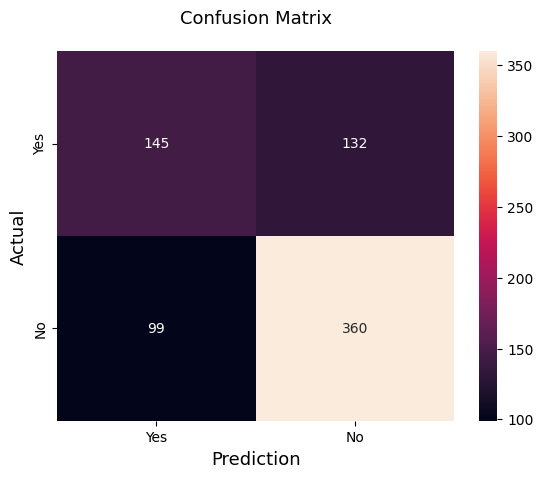




------KNN Classifier-----
KNNS
Model Prerformance: KNeighborsClassifierEnglish_KNeighborsClassifier_20260408__0.732
Accuracy: 0.742
Precision: 0.738
Recall: 0.742
F1 Score: 0.732
Confusion Matrix

[Yes  No]
[[147 130]
 [ 60 399]]


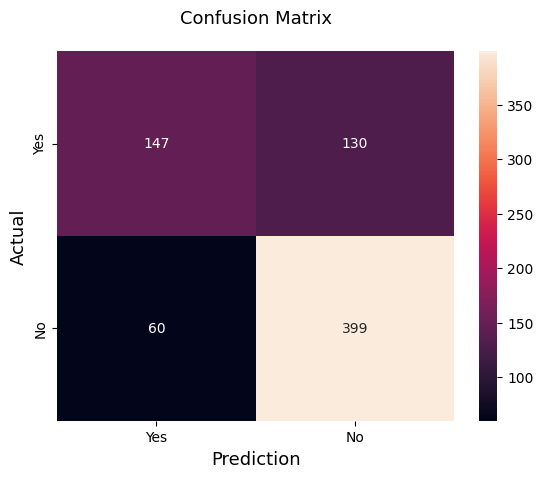




,,,,,,XGB Classifier,,,,,,
XGB
Model Prerformance: XGBClassifierEnglish_XGBClassifier_20260408__0.769
Accuracy: 0.783
Precision: 0.792
Recall: 0.783
F1 Score: 0.769
Confusion Matrix

[Yes  No]
[[146 131]
 [ 29 430]]


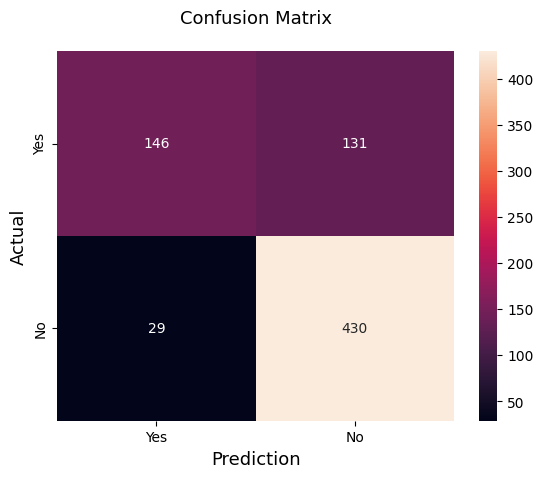




!!!!!!Random Forest Classifier!!!!!!!
RFC
Model Prerformance: RandomForestClassifierEnglish_RandomForestClassifier_20260408__0.732
Accuracy: 0.753
Precision: 0.764
Recall: 0.753
F1 Score: 0.732
Confusion Matrix

[Yes  No]
[[125 152]
 [ 30 429]]


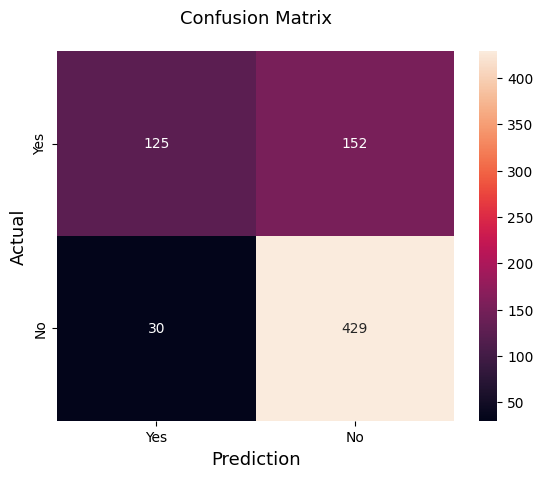




~~~~~~~Gradient Boosting Classifier~~~~~~~
GDB
Model Prerformance: GradientBoostingClassifierEnglish_GradientBoostingClassifier_20260408__0.746
Accuracy: 0.765
Precision: 0.779
Recall: 0.765
F1 Score: 0.746
Confusion Matrix

[Yes  No]
[[130 147]
 [ 26 433]]


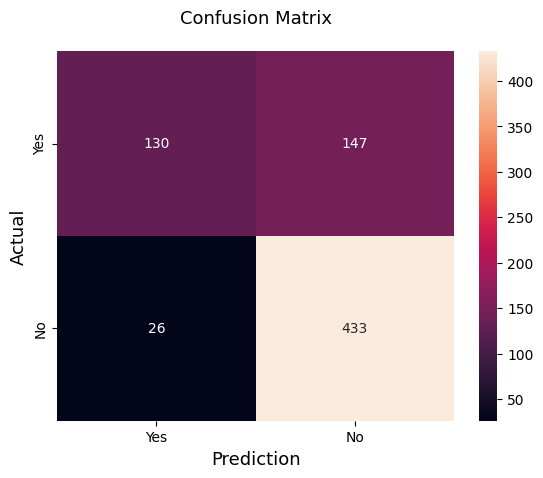




~~~~~~~~Light GBM Classifier~~~~~~~~
LGBM
[LightGBM] [Warning] Unknown parameter: andom_state
[LightGBM] [Warning] feature_fraction is set=0.6424202471887338, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6424202471887338
[LightGBM] [Warning] lambda_l2 is set=0.6095643339798968, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.6095643339798968
[LightGBM] [Warning] lambda_l1 is set=0.036886947354532795, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.036886947354532795
[LightGBM] [Warning] bagging_fraction is set=0.856135294962221, subsample=1.0 will be ignored. Current value: bagging_fraction=0.856135294962221
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] Unknown parameter: andom_state
[LightGBM] [Warning] feature_fraction is set=0.6424202471887338, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6424202471887338
[LightGBM] [Warning

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] Unknown parameter: andom_state
[LightGBM] [Warning] feature_fraction is set=0.6424202471887338, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6424202471887338
[LightGBM] [Warning] lambda_l2 is set=0.6095643339798968, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.6095643339798968
[LightGBM] [Warning] lambda_l1 is set=0.036886947354532795, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.036886947354532795
[LightGBM] [Warning] bagging_fraction is set=0.856135294962221, subsample=1.0 will be ignored. Current value: bagging_fraction=0.856135294962221
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
Model Prerformance: LightGBMClassifierEnglish_LGBMClassifier_20260408__0.73
Accuracy: 0.758
Precision: 0.792
Recall: 0.758
F1 Score: 0.730
Confusion Matrix

[Yes  No]
[[112 165]
 [ 13 446]]


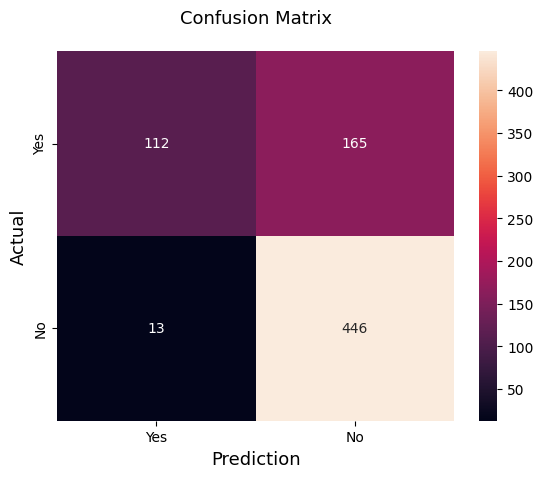




~~~~~~~~~~~Ada Boost Classifier~~~~~~~~~~~
AdaBoost
Model Prerformance: AdaBoostClassifierEnglish_AdaBoostClassifier_20260408__0.718
Accuracy: 0.750
Precision: 0.786
Recall: 0.750
F1 Score: 0.718
Confusion Matrix

[Yes  No]
[[106 171]
 [ 13 446]]


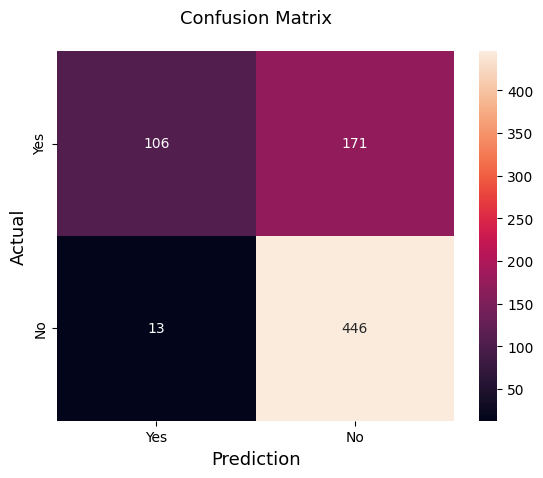




Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


Model Prerformance: logistic_regressionEnglish_LogisticRegression_20260408__0.773
Accuracy: 0.777
Precision: 0.774
Recall: 0.777
F1 Score: 0.773
Confusion Matrix

[Yes  No]
[[174 103]
 [ 61 398]]


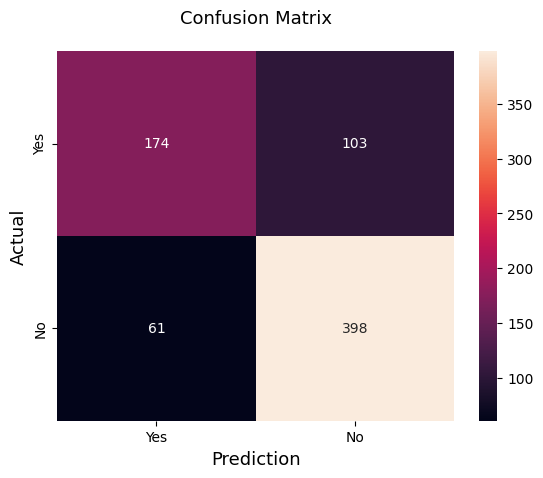




......Voatinng Classifier Soft.....
Classifiers used: ['dt', 'knn', 'rf', 'xgb']
Model Prerformance: VotingClassifier_dt_knn_rf_xgbEnglish_VotingClassifier_20260408__0.776
Accuracy: 0.787
Precision: 0.791
Recall: 0.787
F1 Score: 0.776
Confusion Matrix

[Yes  No]
[[155 122]
 [ 35 424]]


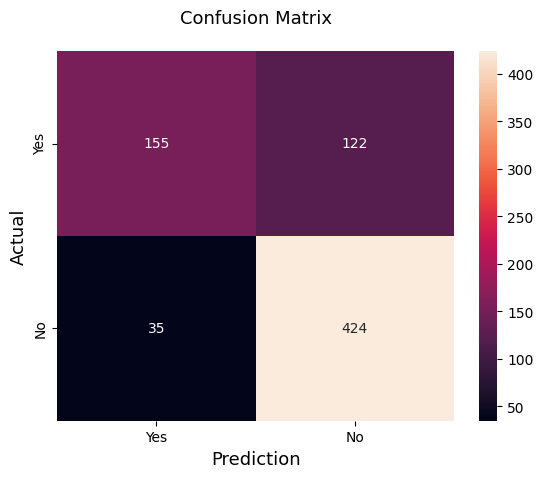

Classifiers used: ['xgb', 'gdb', 'lr']


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


Model Prerformance: VotingClassifier_xgb_gdb_lrEnglish_VotingClassifier_20260408__0.77
Accuracy: 0.783
Precision: 0.790
Recall: 0.783
F1 Score: 0.770
Confusion Matrix

[Yes  No]
[[148 129]
 [ 31 428]]


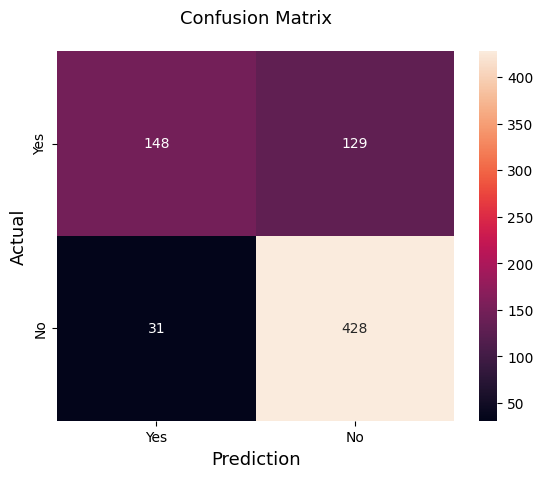




......Voatinng Classifier Hard.....
Classifiers used: ['dt', 'knn', 'rf', 'xgb']
Model Prerformance: VotingClassifier_dt_knn_rf_xgbEnglish_VotingClassifier_20260408__0.741
Accuracy: 0.765
Precision: 0.791
Recall: 0.765
F1 Score: 0.741
Confusion Matrix

[Yes  No]
[[121 156]
 [ 17 442]]


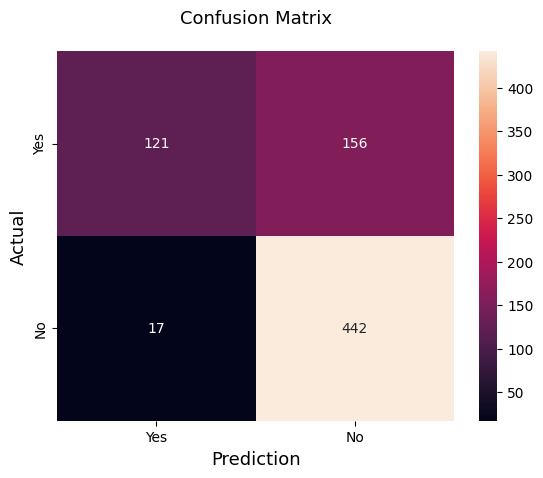

Classifiers used: ['xgb', 'lgbm', 'adb', 'lr']
[LightGBM] [Warning] Unknown parameter: andom_state
[LightGBM] [Warning] feature_fraction is set=0.6424202471887338, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6424202471887338
[LightGBM] [Warning] lambda_l2 is set=0.6095643339798968, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.6095643339798968
[LightGBM] [Warning] lambda_l1 is set=0.036886947354532795, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.036886947354532795
[LightGBM] [Warning] bagging_fraction is set=0.856135294962221, subsample=1.0 will be ignored. Current value: bagging_fraction=0.856135294962221
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] Unknown parameter: andom_state
[LightGBM] [Warning] feature_fraction is set=0.6424202471887338, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6424202471887338
[LightGBM] [Warni

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] Unknown parameter: andom_state
[LightGBM] [Warning] feature_fraction is set=0.6424202471887338, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6424202471887338
[LightGBM] [Warning] lambda_l2 is set=0.6095643339798968, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.6095643339798968
[LightGBM] [Warning] lambda_l1 is set=0.036886947354532795, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.036886947354532795
[LightGBM] [Warning] bagging_fraction is set=0.856135294962221, subsample=1.0 will be ignored. Current value: bagging_fraction=0.856135294962221
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
Model Prerformance: VotingClassifier_xgb_lgbm_adb_lrEnglish_VotingClassifier_20260408__0.729
Accuracy: 0.758
Precision: 0.794
Recall: 0.758
F1 Score: 0.729
Confusion Matrix

[Yes  No]
[[111 166]
 [ 12 447]]


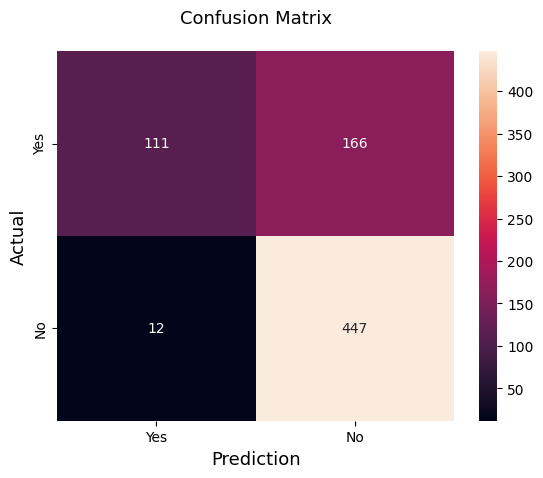

Classifiers used: ['xgb', 'gdb', 'lr']


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


Model Prerformance: VotingClassifier_xgb_gdb_lrEnglish_VotingClassifier_20260408__0.761
Accuracy: 0.776
Precision: 0.786
Recall: 0.776
F1 Score: 0.761
Confusion Matrix

[Yes  No]
[[141 136]
 [ 29 430]]


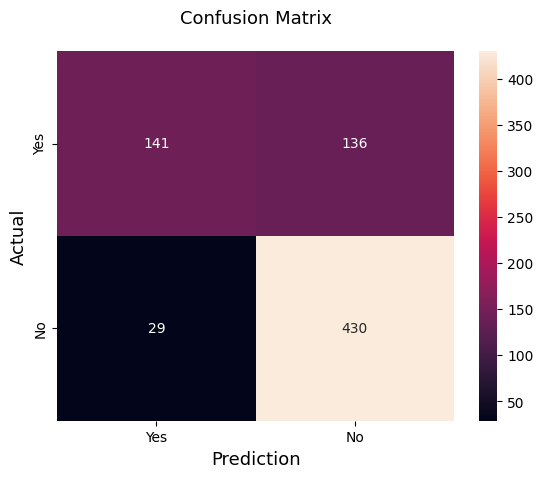




......Blending Classifier.....


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(



In __train_level_1(self, final_learner, train_meta_model, test_meta_model, name)

Calling __check_metrics_save_model(final_learner, test_preds, name)

Model Prerformance: blending_xgb_lr_English_LogisticRegression_20260408__0.479
Accuracy: 0.624
Precision: 0.389
Recall: 0.624
F1 Score: 0.479
Confusion Matrix

[Yes  No]
[[  0 277]
 [  0 459]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


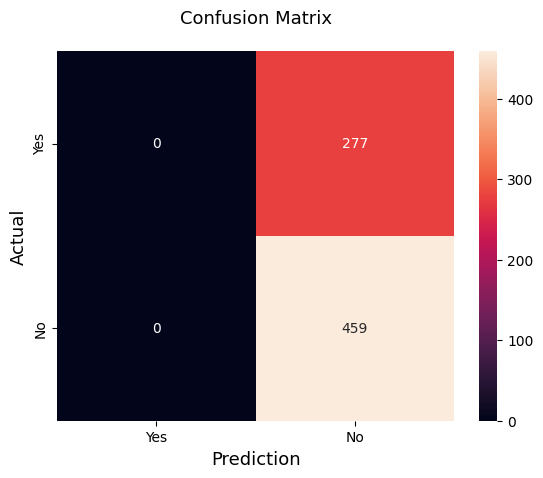




......Stacking Classifier.....
['xgb', 'lr']
xgb
In  __k_fold_cross_validation(self, clf)

xgb
785

In __stacking_traini_level_0(self, model)

lr
In  __k_fold_cross_validation(self, clf)

lr
785


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(



In __stacking_traini_level_0(self, model)



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(



In __stacking_train_level_1(self, final_learner, train_meta_model, test_meta_model, name)

Model Prerformance: stacking_xgb_lr_English_LogisticRegression_20260408__0.479
Accuracy: 0.624
Precision: 0.389
Recall: 0.624
F1 Score: 0.479
Confusion Matrix

[Yes  No]
[[  0 277]
 [  0 459]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


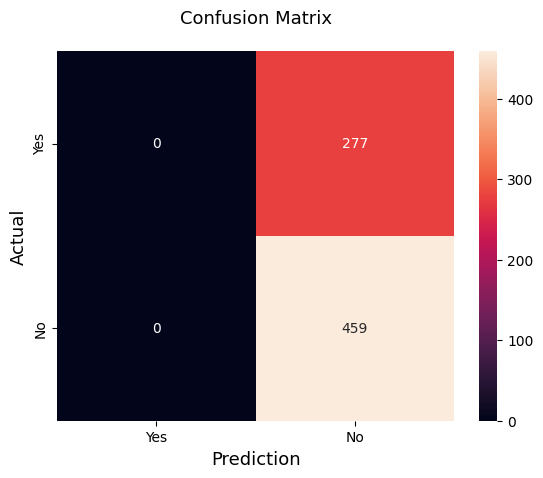




Pipeline completed successfully!


In [ ]:
obj = Ensemble(X_train,
              y_train.tolist(),
              X_val, y_val.tolist(),
              X_test,
              y_test.tolist(),
              best_param_dt,
              best_param_xgb,
              best_param_rfc,
              best_param_knn,
              best_param_gdb,
              best_param_lgbm,
              best_param_adb,
              best_param_lr,
              language = "English")
obj.run_pipeline()